In [15]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="species")

print(X.head())
print(y.value_counts())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
species
0    50
1    50
2    50
Name: count, dtype: int64


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
      X,
      y,
      test_size=0.20,
      random_state=42,
      stratify=y,
  )

print("Training rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])

Training rows: 120
Test rows: 30


In [17]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

dummy_predictions = dummy.predict(X_test)
print("Dummy baseline accuracy:", accuracy_score(y_test, dummy_predictions))

Dummy baseline accuracy: 0.3333333333333333


In [18]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

models = {
      "Logistic Regression": Pipeline([
          ("scaler", StandardScaler()),
          ("model", LogisticRegression(max_iter=1000)),
      ]),
      "k-Nearest Neighbors": Pipeline([
          ("scaler", StandardScaler()),
          ("model", KNeighborsClassifier(n_neighbors=5)),
      ]),
      "Decision Tree": DecisionTreeClassifier(random_state=42),
  }

In [19]:
results = []

for name, model in models.items():
      model.fit(X_train, y_train)
      predictions = model.predict(X_test)

      results.append({
          "Model": name,
          "Test accuracy": accuracy_score(y_test, predictions),
      })

results_df = pd.DataFrame(results).sort_values(
      by="Test accuracy",
      ascending=False,
  )

results_df

,Model,Test accuracy
0,Logistic Regression,0.933333
1,k-Nearest Neighbors,0.933333
2,Decision Tree,0.933333


In [20]:
from sklearn.model_selection import cross_val_score

cv_results = []

for name, model in models.items():
      scores = cross_val_score(
          model,
          X_train,
          y_train,
          cv=5,
          scoring="accuracy",
      )

      cv_results.append({
          "Model": name,
          "Mean CV accuracy": scores.mean(),
          "Variation": scores.std(),
      })

cv_results_df = pd.DataFrame(cv_results).sort_values(
      by="Mean CV accuracy",
      ascending=False,
  )

cv_results_df

,Model,Mean CV accuracy,Variation
1,k-Nearest Neighbors,0.966667,0.031180
0,Logistic Regression,0.958333,0.026352
2,Decision Tree,0.941667,0.020412


In [21]:
best_model = models["k-Nearest Neighbors"]

best_model.fit(X_train, y_train)
final_predictions = best_model.predict(X_test)

print("Final test accuracy:", accuracy_score(y_test, final_predictions))

Final test accuracy: 0.9333333333333333


In [22]:
from sklearn.metrics import classification_report

print(
      classification_report(
          y_test,
          final_predictions,
          target_names=iris.target_names,
      )
  )

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



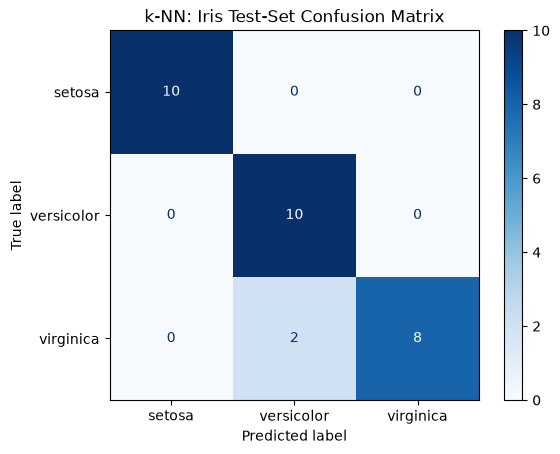

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
      y_test,
      final_predictions,
      display_labels=iris.target_names,
      cmap="Blues",
  )

plt.title("k-NN: Iris Test-Set Confusion Matrix")
plt.show()

In [ ]:
## Conclusion

##I compared Logistic Regression, k-Nearest Neighbors, and a Decision Tree on the Iris classification
##dataset.

##The dummy baseline achieved 33.3% accuracy, while all real models achieved 93.3% accuracy on the
##held-out test set. Five-fold cross-validation selected k-Nearest Neighbors as the best model, with
##an average accuracy of 96.7%.

##The final k-NN model correctly classified all setosa samples and most versicolor and virginica
##samples. Its main mistakes were confusing two virginica flowers with versicolor flowers.

##This exercise demonstrated the complete supervised-learning workflow: data loading, splitting,
##baseline comparison, training, cross-validation, final evaluation, and confusion-matrix
##interpretation.